# House Price Prediction
## Dataset: Kaggle House Price Dataset

## Bước 1: Khai báo thư viện & Nạp tập dữ liệu ban đầu

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# Thiết lập Random Seed cố định để đảm bảo tính tái lập (Reproducibility)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 1. Đọc dữ liệu bất động sản từ file CSV
df = pd.read_csv('../../DATA/vietnam_housing_dataset.csv')

print("="*65)
print(f"📊 KÍCH THƯỚC TẬP DỮ LIỆU BAN ĐẦU: {df.shape[0]} dòng, {df.shape[1]} thuộc tính")
print("="*65)
df.head()

## Bước 2: Khảo sát chất lượng, Làm sạch & Kỹ nghệ đặc trưng (Data Quality & Cleaning)

In [3]:
print("1. THÔNG TIN CẤU TRÚC VÀ KIỂU DỮ LIỆU:")
print(df.info())

print("\n2. KIỂM TRA GIÁ TRỊ KHUYẾT THIẾU BAN ĐẦU (MISSING VALUES):")
print(df.isna().sum())

print("\n3. KIỂM TRA BẢN GHI TRÙNG LẶP (DUPLICATES):")
duplicate_count = df.duplicated().sum()
print(f"Số lượng bản ghi trùng lặp: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"-> Đã loại bỏ {duplicate_count} dòng trùng lặp.")

# 4. KỸ NGHỆ ĐẶC TRƯNG VÀ XỬ LÝ DỮ LIỆU
# Trích xuất Tỉnh/Thành phố từ địa chỉ và chuẩn hóa tên chuỗi
def extract_location(addr):
    if pd.isna(addr):
        return 'Unknown'
    parts = str(addr).split(',')
    loc = parts[-1].strip()
    return loc if len(loc) > 0 else 'Unknown'

if 'Address' in df.columns:
    df['Province'] = df['Address'].apply(extract_location)
    df = df.drop(columns=['Address'])

# Xử lý giá trị khuyết:
# Biến định lượng: ép kiểu số và điền giá trị trung vị (median)
num_cols = ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# Biến phân loại: điền nhãn 'Unknown'
cat_cols = ['House direction', 'Balcony direction', 'Legal status', 'Furniture state', 'Province']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown').astype(str).str.strip()

# Loại bỏ các dòng thiếu nhãn mục tiêu Price hoặc giá trị không hợp lệ
df = df.dropna(subset=['Price'])
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df = df[df['Price'] > 0]

# Xử lý giá trị ngoại lai (Outlier Treatment)
# Giới hạn diện tích thực tế và loại bỏ top 1% giá trị biên cực đoan
df = df[(df['Area'] >= 10) & (df['Area'] <= df['Area'].quantile(0.99))]
df = df[df['Price'] <= df['Price'].quantile(0.99)].reset_index(drop=True)

print(f"\n5. KÍCH THƯỚC DỮ LIỆU SAU KHI LÀM SẠCH VÀ LỌC NGOẠI LAI: {df.shape[0]} dòng, {df.shape[1]} cột")

1. THÔNG TIN CẤU TRÚC VÀ KIỂU DỮ LIỆU:
<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 5.4 MB
None

2. KIỂM TRA GIÁ TRỊ KHUYẾT THIẾU BAN ĐẦU (MISSING VALUES):
Address                  0
Area                     0
Frontage             115

## Bước 3: Biểu diễn dữ liệu số học

In [6]:
import numpy as np
import pandas as pd
import json

# 1. Mã hóa One-Hot Encoding cho các biến phân loại
categorical_features = ['House direction', 'Balcony direction', 'Legal status', 'Furniture state', 'Province']
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# 2. Tách biến độc lập (X) và biến mục tiêu liên tục (y)
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

# 3. Biểu diễn số học dưới dạng Vector, Ma trận và Tensor
# A. Vector đặc trưng của một căn nhà mẫu: x_1 in R^d
sample_vector = X.iloc[0].to_numpy(dtype=np.float32)

# B. Ma trận đặc trưng toàn phần: X in R^(N x d) và Vector mục tiêu: y in R^N
feature_matrix = X.to_numpy(dtype=np.float32)
target_vector = y.to_numpy(dtype=np.float32)

# C. Biểu diễn Tensor tính toán (PyTorch Tensor hoặc NumPy NDArray)
try:
    import torch
    tensor_X = torch.tensor(feature_matrix, dtype=torch.float32)
    tensor_y = torch.tensor(target_vector, dtype=torch.float32)
    tensor_info = f"PyTorch Tensor (X: {tensor_X.shape}, y: {tensor_y.shape})"
except ImportError:
    tensor_info = f"NumPy Tensor/NDArray (X: {feature_matrix.shape}, y: {target_vector.shape})"

# Lưu danh sách tên cột để đồng bộ thứ tự đặc trưng cho Flask API
with open('house_model_columns.json', 'w', encoding='utf-8') as f:
    json.dump(list(X.columns), f, ensure_ascii=False)

print("="*75)
print("📐 ĐO LƯỜNG VÀ BIỂU DIỄN DỮ LIỆU SỐ HỌC (HOUSE PRICE REPRESENTATION):")
print(f"1. Vector đặc trưng mẫu x_1 in R^{len(sample_vector)}:")
print(f"   Shape: {sample_vector.shape} -> 6 thuộc tính số học đầu tiên: {sample_vector[:6]}")
print(f"\n2. Ma trận đặc trưng toàn phần (Feature Matrix X) in R^(N x d):")
print(f"   Shape: {feature_matrix.shape} (N={feature_matrix.shape[0]} bất động sản, d={feature_matrix.shape[1]} đặc trưng)")
print(f"   Vector nhãn mục tiêu y in R^N: Shape {target_vector.shape} (Giá trị liên tục - Tỷ VNĐ)")
print(f"\n3. Biểu diễn Tensor tính toán:")
print(f"   {tensor_info}")
print("📁 Đã lưu cấu hình: 'house_model_columns.json'")
print("="*75)

📐 ĐO LƯỜNG VÀ BIỂU DIỄN DỮ LIỆU SỐ HỌC (HOUSE PRICE REPRESENTATION):
1. Vector đặc trưng mẫu x_1 in R^129:
   Shape: (129,) -> 6 thuộc tính số học đầu tiên: [84.   4.5  6.   4.   3.   3. ]

2. Ma trận đặc trưng toàn phần (Feature Matrix X) in R^(N x d):
   Shape: (29910, 129) (N=29910 bất động sản, d=129 đặc trưng)
   Vector nhãn mục tiêu y in R^N: Shape (29910,) (Giá trị liên tục - Tỷ VNĐ)

3. Biểu diễn Tensor tính toán:
   NumPy Tensor/NDArray (X: (29910, 129), y: (29910,))
📁 Đã lưu cấu hình: 'house_model_columns.json'


## Bước 4: Phân tích & Khám phá dữ liệu (Exploratory Data Analysis - EDA)

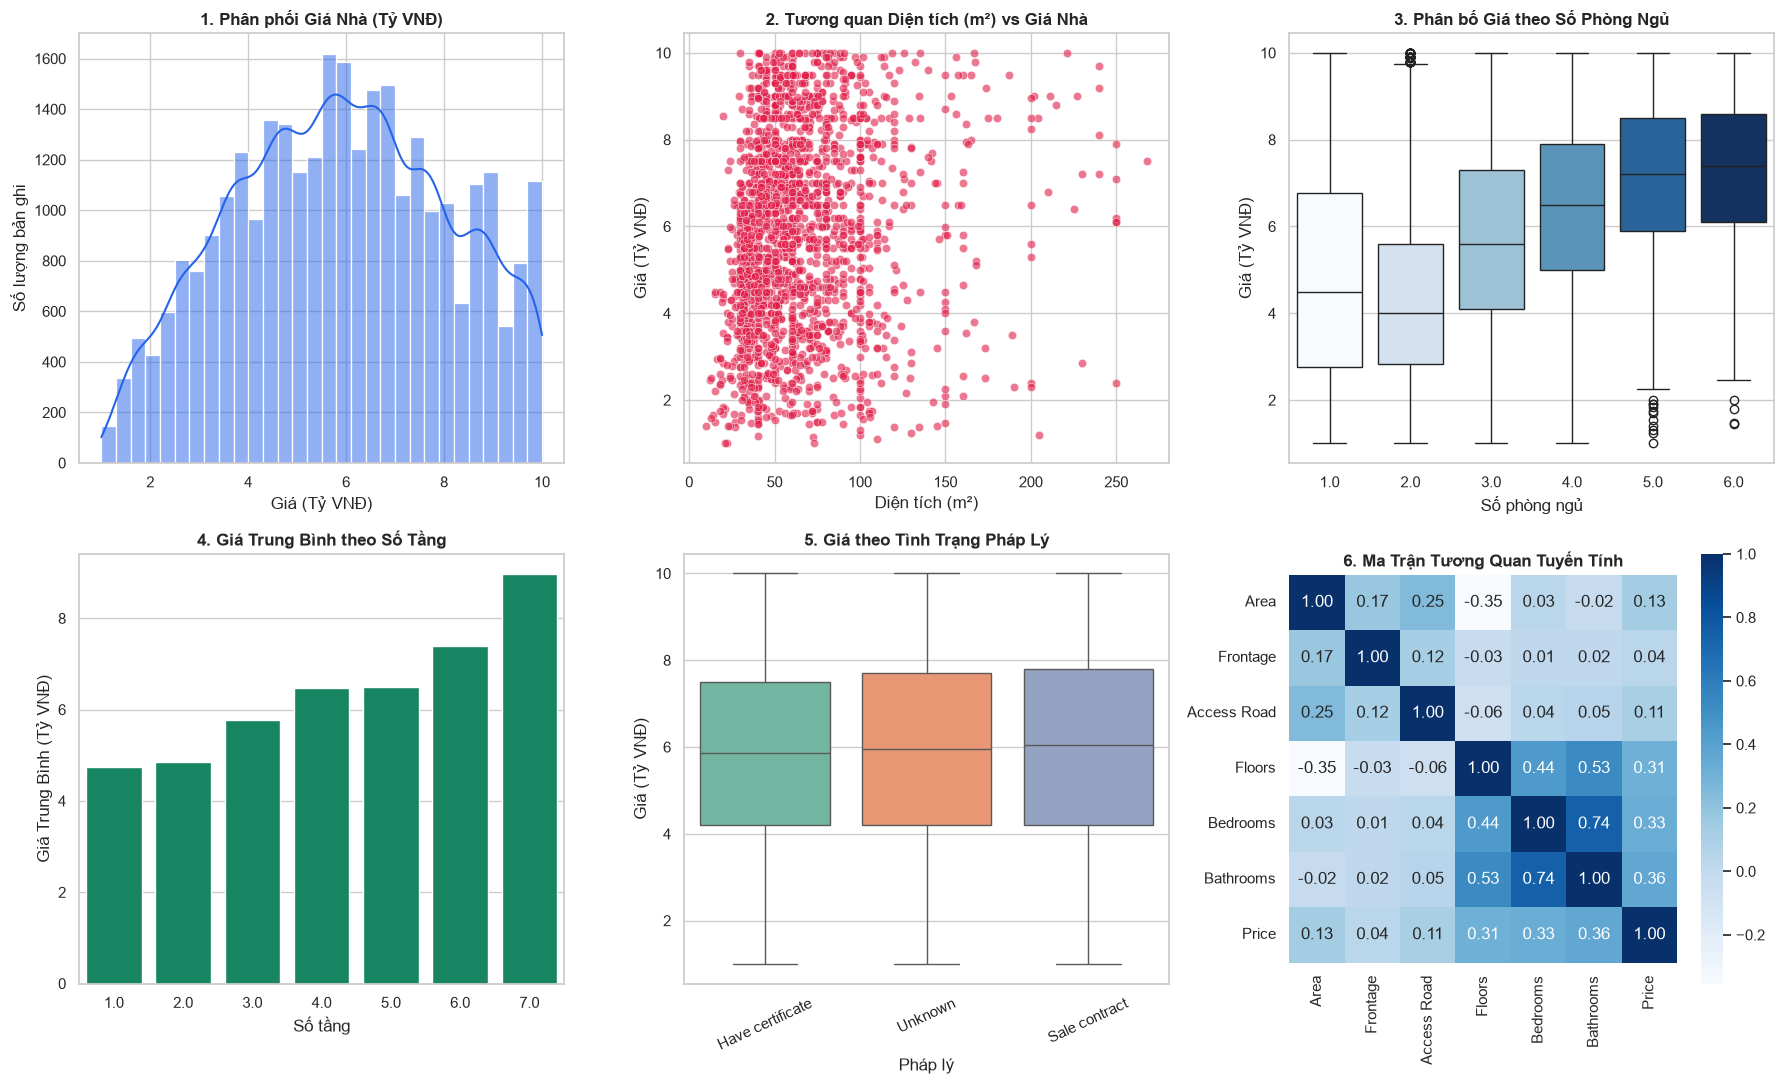

In [4]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Phân phối Giá nhà (Histogram + KDE)
sns.histplot(df['Price'], kde=True, color='#2563eb', bins=30, ax=axes[0, 0])
axes[0, 0].set_title('1. Phân phối Giá Nhà (Tỷ VNĐ)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Giá (Tỷ VNĐ)')
axes[0, 0].set_ylabel('Số lượng bản ghi')

# 2. Tương quan Diện tích vs Giá Nhà (Scatter Plot)
sample_df = df.sample(n=min(2000, len(df)), random_state=RANDOM_SEED)
sns.scatterplot(data=sample_df, x='Area', y='Price', alpha=0.6, color='#e11d48', ax=axes[0, 1])
axes[0, 1].set_title('2. Tương quan Diện tích (m²) vs Giá Nhà', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Diện tích (m²)')
axes[0, 1].set_ylabel('Giá (Tỷ VNĐ)')

# 3. So sánh Giá theo Số phòng ngủ (Boxplot)
bedroom_subset = df[df['Bedrooms'] <= 6]
sns.boxplot(data=bedroom_subset, x='Bedrooms', y='Price', hue='Bedrooms', palette='Blues', legend=False, ax=axes[0, 2])
axes[0, 2].set_title('3. Phân bố Giá theo Số Phòng Ngủ', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Số phòng ngủ')
axes[0, 2].set_ylabel('Giá (Tỷ VNĐ)')

# 4. Giá trung bình theo Số tầng (Barplot)
floor_subset = df[df['Floors'] <= 7]
sns.barplot(data=floor_subset, x='Floors', y='Price', color='#059669', errorbar=None, ax=axes[1, 0])
axes[1, 0].set_title('4. Giá Trung Bình theo Số Tầng', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Số tầng')
axes[1, 0].set_ylabel('Giá Trung Bình (Tỷ VNĐ)')

# 5. Giá nhà theo Tình trạng Pháp lý (Boxplot)
sns.boxplot(data=df, x='Legal status', y='Price', hue='Legal status', palette='Set2', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('5. Giá theo Tình Trạng Pháp Lý', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Pháp lý')
axes[1, 1].set_ylabel('Giá (Tỷ VNĐ)')
axes[1, 1].tick_params(axis='x', rotation=25)

# 6. Ma trận tương quan giữa các biến định lượng (Heatmap)
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='Blues', square=True, ax=axes[1, 2])
axes[1, 2].set_title('6. Ma Trận Tương Quan Tuyến Tính', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Bước 5: Phân chia tập dữ liệu & Chuẩn hóa thang đo

In [7]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Chia tập Train (80%) và Test (20%) - Dành cho bài toán Hồi quy (không dùng stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)

# 2. Chuẩn hóa Z-score (Chỉ fit trên X_train để chống rò rỉ dữ liệu - Data Leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Lưu bộ tham số chuẩn hóa
joblib.dump(scaler, 'scaler_house.pkl')

print("="*75)
print("📊 KÍCH THƯỚC MA TRẬN ĐẦU VÀO SAU CHUẨN HÓA (MODEL INPUT):")
print(f"- Ma trận Train sau Scaling : {X_train_scaled.shape}")
print(f"- Ma trận Test sau Scaling  : {X_test_scaled.shape}")
print(f"- Mean của cột 0 trên Train : {X_train_scaled[:, 0].mean():.4f} (Gần bằng 0)")
print(f"- Std của cột 0 trên Train  : {X_train_scaled[:, 0].std():.4f} (Bằng 1)")
print("📁 Đã lưu bộ chuẩn hóa: 'scaler_house.pkl'")
print("="*75)

📊 KÍCH THƯỚC MA TRẬN ĐẦU VÀO SAU CHUẨN HÓA (MODEL INPUT):
- Ma trận Train sau Scaling : (23928, 129)
- Ma trận Test sau Scaling  : (5982, 129)
- Mean của cột 0 trên Train : 0.0000 (Gần bằng 0)
- Std của cột 0 trên Train  : 1.0000 (Bằng 1)
📁 Đã lưu bộ chuẩn hóa: 'scaler_house.pkl'


## Bước 6: Huấn luyện 5 mô hình & Đánh giá 5 độ đo

In [12]:
# Tạo danh sách để lưu kết quả đánh giá của từng model
results = []
trained_models = {}
print("✅ Sẵn sàng huấn luyện các mô hình!")

✅ Sẵn sàng huấn luyện các mô hình!


### Mô hình 1: K-Nearest Neighbors (KNN)
(KNN dựa trên khoảng cách hình học nên sử dụng tập dữ liệu đã chuẩn hóa X_train_scaled, X_test_scaled)

In [9]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("⏳ [1/5] Đang huấn luyện mô hình K-Nearest Neighbors (KNN)...")

# 1. Huấn luyện (sử dụng dữ liệu đã chuẩn hóa)
knn_model = KNeighborsRegressor(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)

# 2. Dự đoán
y_pred_knn = knn_model.predict(X_test_scaled)

# 3. Tính toán các chỉ số đánh giá
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)
mape_knn = np.mean(np.abs((y_test - y_pred_knn) / y_test)) * 100

# 4. Lưu kết quả
trained_models["K-Nearest Neighbors (KNN)"] = knn_model
results.append({
    "Model": "K-Nearest Neighbors (KNN)",
    "R2-Score": round(r2_knn, 4),
    "MAE (Tỷ)": round(mae_knn, 3),
    "RMSE (Tỷ)": round(rmse_knn, 3),
    "MAPE (%)": round(mape_knn, 2)
})

# In chi tiết kết quả
print("\n" + "="*55)
print("🎯 KẾT QUẢ ĐÁNH GIÁ: K-Nearest Neighbors (KNN)")
print("="*55)
print(f"1. R²-Score (Hệ số xác định)      : {r2_knn:.4f}")
print(f"2. MAE     (Sai số tuyệt đối TB) : {mae_knn:.3f} Tỷ VNĐ")
print(f"3. RMSE    (Căn bậc hai MSE)      : {rmse_knn:.3f} Tỷ VNĐ")
print(f"4. MAPE    (Sai số phần trăm TB) : {mape_knn:.2f}%")
print("="*55)

⏳ [1/5] Đang huấn luyện mô hình K-Nearest Neighbors (KNN)...

🎯 KẾT QUẢ ĐÁNH GIÁ: K-Nearest Neighbors (KNN)
1. R²-Score (Hệ số xác định)      : 0.3496
2. MAE     (Sai số tuyệt đối TB) : 1.358 Tỷ VNĐ
3. RMSE    (Căn bậc hai MSE)      : 1.743 Tỷ VNĐ
4. MAPE    (Sai số phần trăm TB) : 29.51%


### Mô hình 2: Ridge Regression

In [13]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("⏳ [2/5] Đang huấn luyện mô hình Ridge Regression...")

# 1. Huấn luyện (sử dụng dữ liệu đã chuẩn hóa)
ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# 2. Dự đoán
y_pred_ridge = ridge_model.predict(X_test_scaled)

# 3. Tính toán các chỉ số đánh giá
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
mape_ridge = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100

# 4. Lưu kết quả
trained_models["Ridge Regression"] = ridge_model
results.append({
    "Model": "Ridge Regression",
    "R2-Score": round(r2_ridge, 4),
    "MAE (Tỷ)": round(mae_ridge, 3),
    "RMSE (Tỷ)": round(rmse_ridge, 3),
    "MAPE (%)": round(mape_ridge, 2)
})

# In chi tiết kết quả
print("\n" + "="*55)
print("🎯 KẾT QUẢ ĐÁNH GIÁ: Ridge Regression")
print("="*55)
print(f"1. R²-Score (Hệ số xác định)      : {r2_ridge:.4f}")
print(f"2. MAE     (Sai số tuyệt đối TB) : {mae_ridge:.3f} Tỷ VNĐ")
print(f"3. RMSE    (Căn bậc hai MSE)      : {rmse_ridge:.3f} Tỷ VNĐ")
print(f"4. MAPE    (Sai số phần trăm TB) : {mape_ridge:.2f}%")
print("="*55)

⏳ [2/5] Đang huấn luyện mô hình Ridge Regression...

🎯 KẾT QUẢ ĐÁNH GIÁ: Ridge Regression
1. R²-Score (Hệ số xác định)      : 0.3527
2. MAE     (Sai số tuyệt đối TB) : 1.383 Tỷ VNĐ
3. RMSE    (Căn bậc hai MSE)      : 1.738 Tỷ VNĐ
4. MAPE    (Sai số phần trăm TB) : 31.17%


### Mô hình 3: Decision Tree

In [10]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("⏳ [3/5] Đang huấn luyện mô hình Decision Tree Regressor...")

# 1. Huấn luyện (dùng trực tiếp X_train gốc)
dt_model = DecisionTreeRegressor(max_depth=8, random_state=42)
dt_model.fit(X_train, y_train)

# 2. Dự đoán
y_pred_dt = dt_model.predict(X_test)

# 3. Tính toán các chỉ số đánh giá
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)
mape_dt = np.mean(np.abs((y_test - y_pred_dt) / y_test)) * 100

# 4. Lưu kết quả
trained_models["Decision Tree"] = dt_model
results.append({
    "Model": "Decision Tree",
    "R2-Score": round(r2_dt, 4),
    "MAE (Tỷ)": round(mae_dt, 3),
    "RMSE (Tỷ)": round(rmse_dt, 3),
    "MAPE (%)": round(mape_dt, 2)
})

# In chi tiết kết quả
print("\n" + "="*55)
print("🎯 KẾT QUẢ ĐÁNH GIÁ: Decision Tree Regressor")
print("="*55)
print(f"1. R²-Score (Hệ số xác định)      : {r2_dt:.4f}")
print(f"2. MAE     (Sai số tuyệt đối TB) : {mae_dt:.3f} Tỷ VNĐ")
print(f"3. RMSE    (Căn bậc hai MSE)      : {rmse_dt:.3f} Tỷ VNĐ")
print(f"4. MAPE    (Sai số phần trăm TB) : {mape_dt:.2f}%")
print("="*55)

⏳ [3/5] Đang huấn luyện mô hình Decision Tree Regressor...

🎯 KẾT QUẢ ĐÁNH GIÁ: Decision Tree Regressor
1. R²-Score (Hệ số xác định)      : 0.3945
2. MAE     (Sai số tuyệt đối TB) : 1.325 Tỷ VNĐ
3. RMSE    (Căn bậc hai MSE)      : 1.681 Tỷ VNĐ
4. MAPE    (Sai số phần trăm TB) : 29.61%


### Mô hình 4: Random Forest

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("⏳ [4/5] Đang huấn luyện mô hình Random Forest Regressor...")

# 1. Huấn luyện (dùng X_train gốc, kích hoạt song song đa nhân n_jobs=-1)
rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. Dự đoán
y_pred_rf = rf_model.predict(X_test)

# 3. Tính toán các chỉ số đánh giá
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

# 4. Lưu kết quả
trained_models["Random Forest"] = rf_model
results.append({
    "Model": "Random Forest",
    "R2-Score": round(r2_rf, 4),
    "MAE (Tỷ)": round(mae_rf, 3),
    "RMSE (Tỷ)": round(rmse_rf, 3),
    "MAPE (%)": round(mape_rf, 2)
})

# In chi tiết kết quả
print("\n" + "="*55)
print("🎯 KẾT QUẢ ĐÁNH GIÁ: Random Forest Regressor")
print("="*55)
print(f"1. R²-Score (Hệ số xác định)      : {r2_rf:.4f}")
print(f"2. MAE     (Sai số tuyệt đối TB) : {mae_rf:.3f} Tỷ VNĐ")
print(f"3. RMSE    (Căn bậc hai MSE)      : {rmse_rf:.3f} Tỷ VNĐ")
print(f"4. MAPE    (Sai số phần trăm TB) : {mape_rf:.2f}%")
print("="*55)

⏳ [4/5] Đang huấn luyện mô hình Random Forest Regressor...

🎯 KẾT QUẢ ĐÁNH GIÁ: Random Forest Regressor
1. R²-Score (Hệ số xác định)      : 0.4744
2. MAE     (Sai số tuyệt đối TB) : 1.227 Tỷ VNĐ
3. RMSE    (Căn bậc hai MSE)      : 1.566 Tỷ VNĐ
4. MAPE    (Sai số phần trăm TB) : 27.15%


### Mô hình 5: Gradient Boosting

In [12]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("⏳ [5/5] Đang huấn luyện mô hình Gradient Boosting Regressor...")

# 1. Huấn luyện (dùng X_train gốc)
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

# 2. Dự đoán
y_pred_gb = gb_model.predict(X_test)

# 3. Tính toán các chỉ số đánh giá
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)
mape_gb = np.mean(np.abs((y_test - y_pred_gb) / y_test)) * 100

# 4. Lưu kết quả
trained_models["Gradient Boosting"] = gb_model
results.append({
    "Model": "Gradient Boosting",
    "R2-Score": round(r2_gb, 4),
    "MAE (Tỷ)": round(mae_gb, 3),
    "RMSE (Tỷ)": round(rmse_gb, 3),
    "MAPE (%)": round(mape_gb, 2)
})

# In chi tiết kết quả
print("\n" + "="*55)
print("🎯 KẾT QUẢ ĐÁNH GIÁ: Gradient Boosting Regressor")
print("="*55)
print(f"1. R²-Score (Hệ số xác định)      : {r2_gb:.4f}")
print(f"2. MAE     (Sai số tuyệt đối TB) : {mae_gb:.3f} Tỷ VNĐ")
print(f"3. RMSE    (Căn bậc hai MSE)      : {rmse_gb:.3f} Tỷ VNĐ")
print(f"4. MAPE    (Sai số phần trăm TB) : {mape_gb:.2f}%")
print("="*55)

⏳ [5/5] Đang huấn luyện mô hình Gradient Boosting Regressor...

🎯 KẾT QUẢ ĐÁNH GIÁ: Gradient Boosting Regressor
1. R²-Score (Hệ số xác định)      : 0.4818
2. MAE     (Sai số tuyệt đối TB) : 1.227 Tỷ VNĐ
3. RMSE    (Căn bậc hai MSE)      : 1.555 Tỷ VNĐ
4. MAPE    (Sai số phần trăm TB) : 27.10%


### Tổng hợp, So sánh 5 mô hình 

📊 BẢNG TỔNG HỢP SO SÁNH 5 MÔ HÌNH HỒI QUY DỰ ĐOÁN GIÁ NHÀ
                    Model  R2-Score  MAE (Tỷ)  RMSE (Tỷ)  MAPE (%)
        Gradient Boosting    0.4818     1.227      1.555     27.10
            Random Forest    0.4744     1.227      1.566     27.15
            Decision Tree    0.3945     1.325      1.681     29.61
         Ridge Regression    0.3527     1.383      1.738     31.17
K-Nearest Neighbors (KNN)    0.3496     1.358      1.743     29.51


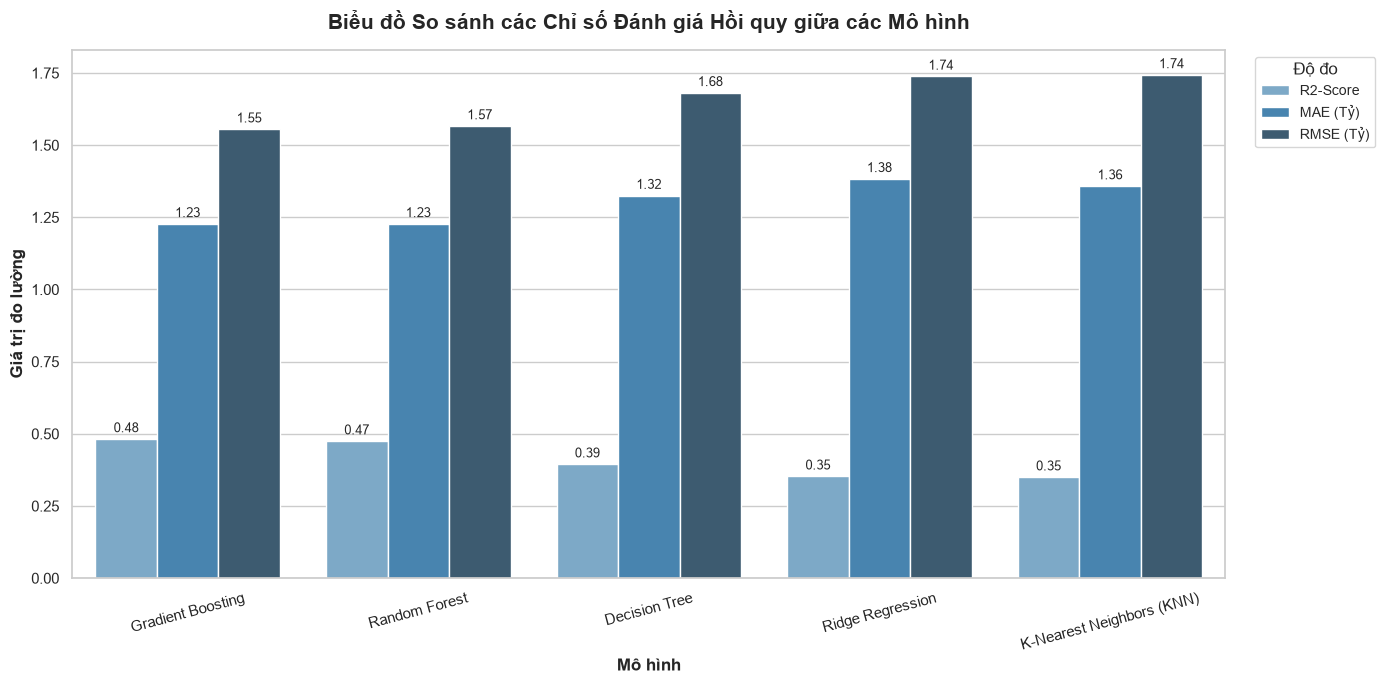


🏆 MÔ HÌNH HỒI QUY TỐT NHẤT: Gradient Boosting
- R²-Score (Độ phù hợp)        : 0.4818
- MAE      (Sai số tuyệt đối TB): 1.227 Tỷ VNĐ
- RMSE     (Căn bậc hai MSE)    : 1.555 Tỷ VNĐ
- MAPE     (Sai số phần trăm TB): 27.1%
📁 Đã xuất các file sẵn sàng cho Flask Backend:
 1. best_house_model.pkl     (Mô hình tốt nhất)
 2. scaler_house.pkl         (Bộ chuẩn hóa dữ liệu)
 3. house_model_columns.json (Danh sách cột đặc trưng)


In [14]:
import json
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. HIỂN THỊ BẢNG TỔNG HỢP SO SÁNH 5 MÔ HÌNH HỒI QUY (Sắp xếp theo R2-Score giảm dần)
df_results = pd.DataFrame(results).sort_values(by="R2-Score", ascending=False).reset_index(drop=True)
print("="*85)
print("📊 BẢNG TỔNG HỢP SO SÁNH 5 MÔ HÌNH HỒI QUY DỰ ĐOÁN GIÁ NHÀ")
print("="*85)
print(df_results.to_string(index=False))

# 2. VẼ BIỂU ĐỒ CỘT SO SÁNH TRỰC QUAN CÁC ĐỘ ĐO HỒI QUY
# Chuyển đổi DataFrame sang dạng dài (melt) để trực quan hóa đa tiêu chí
df_melted = pd.melt(
    df_results, 
    id_vars=['Model'], 
    value_vars=['R2-Score', 'MAE (Tỷ)', 'RMSE (Tỷ)'],
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

chart = sns.barplot(
    data=df_melted, 
    x='Model', 
    y='Score', 
    hue='Metric', 
    palette='Blues_d'
)

plt.title('Biểu đồ So sánh các Chỉ số Đánh giá Hồi quy giữa các Mô hình', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Mô hình', fontsize=12, fontweight='bold')
plt.ylabel('Giá trị đo lường', fontsize=12, fontweight='bold')
plt.xticks(rotation=15, fontsize=11)
plt.legend(title='Độ đo', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)

# Hiển thị số liệu chi tiết trên đỉnh từng cột
for p in chart.patches:
    height = p.get_height()
    if height > 0:
        chart.annotate(f"{height:.2f}",
                       (p.get_x() + p.get_width() / 2., height),
                       ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                       textcoords='offset points')

plt.tight_layout()
plt.show()

# 3. TỰ ĐỘNG CHỌN VÀ LƯU MÔ HÌNH TỐI ƯU NHẤT CÙNG CẤU HÌNH CHO FLASK
best_model_name = df_results.iloc[0]['Model']
best_model_obj = trained_models[best_model_name]

# Lưu mô hình tốt nhất (.pkl)
joblib.dump(best_model_obj, 'best_house_model.pkl')

# Lưu bộ chuẩn hóa StandardScaler (.pkl)
joblib.dump(scaler, 'scaler_house.pkl')

# Lưu danh sách các cột đặc trưng sau One-Hot Encoding (.json) để Flask căn chỉnh đúng ma trận
with open('house_model_columns.json', 'w', encoding='utf-8') as f:
    json.dump(list(X.columns), f, ensure_ascii=False)

print("\n" + "="*85)
print(f"🏆 MÔ HÌNH HỒI QUY TỐT NHẤT: {best_model_name}")
print(f"- R²-Score (Độ phù hợp)        : {df_results.iloc[0]['R2-Score']}")
print(f"- MAE      (Sai số tuyệt đối TB): {df_results.iloc[0]['MAE (Tỷ)']} Tỷ VNĐ")
print(f"- RMSE     (Căn bậc hai MSE)    : {df_results.iloc[0]['RMSE (Tỷ)']} Tỷ VNĐ")
print(f"- MAPE     (Sai số phần trăm TB): {df_results.iloc[0]['MAPE (%)']}%")
print("="*85)
print("📁 Đã xuất các file sẵn sàng cho Flask Backend:")
print(" 1. best_house_model.pkl     (Mô hình tốt nhất)")
print(" 2. scaler_house.pkl         (Bộ chuẩn hóa dữ liệu)")
print(" 3. house_model_columns.json (Danh sách cột đặc trưng)")
print("="*85)

## Bước 7: Khởi chạy Flask API kết nối Front-End

In [15]:
import threading
import json
import joblib
import pandas as pd
from flask import Flask, request, jsonify
from flask_cors import CORS

# 1. Khởi tạo ứng dụng Flask
app = Flask(__name__)
# Kích hoạt CORS để cho phép Front-End (React/Vue/HTML) gửi request chéo nguồn
CORS(app, resources={r"/*": {"origins": "*"}})

# 2. Nạp mô hình tối ưu nhất, scaler và danh sách cột đặc trưng đã lưu
loaded_house_model = joblib.load('best_house_model.pkl')
loaded_house_scaler = joblib.load('scaler_house.pkl')
with open('house_model_columns.json', 'r', encoding='utf-8') as f:
    house_columns = json.load(f)

# Endpoint kiểm tra trạng thái hoạt động của Server
@app.route('/', methods=['GET'])
def health_check():
    return jsonify({
        "status": "online",
        "message": "Flask API House Price Prediction đang hoạt động từ Notebook!"
    })

# Endpoint chính tiếp nhận dữ liệu nhà đất và trả về giá dự đoán
@app.route('/predict_price', methods=['POST', 'OPTIONS'])
def predict_price():
    # Xử lý CORS Preflight request từ trình duyệt
    if request.method == 'OPTIONS':
        return jsonify({"status": "ok"}), 200

    try:
        data = request.get_json()
        if not data:
            return jsonify({"success": False, "message": "Không nhận được dữ liệu đầu vào!"}), 400

        # Chuyển đổi JSON nhận được thành DataFrame
        input_df = pd.DataFrame([data])

        # Trích xuất Tỉnh/Thành từ Address (nếu có)
        if 'Address' in input_df.columns:
            parts = str(input_df['Address'].iloc[0]).split(',')
            input_df['Province'] = parts[-1].strip() if len(parts) > 0 else 'Unknown'
            input_df = input_df.drop(columns=['Address'])

        # Chuyển đổi kiểu số cho các đặc trưng hình học
        num_cols = ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms']
        for col in num_cols:
            if col in input_df.columns:
                input_df[col] = pd.to_numeric(input_df[col], errors='coerce').fillna(0)

        # One-Hot Encoding cho các biến phân loại
        cat_cols = ['House direction', 'Balcony direction', 'Legal status', 'Furniture state', 'Province']
        input_df = pd.get_dummies(input_df, columns=[c for c in cat_cols if c in input_df.columns], drop_first=True)

        # Căn chỉnh ma trận đặc trưng đúng với tập huấn luyện (thiếu cột tự động điền 0)
        input_processed = input_df.reindex(columns=house_columns, fill_value=0)

        # Tự động chuẩn hóa nếu mô hình sử dụng là KNN hoặc Linear/Ridge
        model_name = type(loaded_house_model).__name__
        if model_name in ["KNeighborsRegressor", "Ridge", "LinearRegression", "SVR"]:
            features = loaded_house_scaler.transform(input_processed)
        else:
            features = input_processed

        # Dự đoán giá trị bất động sản
        predicted_raw = float(loaded_house_model.predict(features)[0])
        predicted_price = max(0.1, round(predicted_raw, 2))  # Đảm bảo giá trị trả về luôn dương

        return jsonify({
            "success": True,
            "predicted_price_billion": predicted_price,
            "formatted_price": f"{predicted_price:,.2f} Tỷ VNĐ",
            "model_used": model_name
        })

    except Exception as e:
        return jsonify({"success": False, "error": str(e)}), 500

# 3. Khởi chạy Flask Server trên luồng phụ (Daemon Thread)
def start_flask_server():
    app.run(host='127.0.0.1', port=5000, use_reloader=False)

flask_thread = threading.Thread(target=start_flask_server, daemon=True)
flask_thread.start()

print("="*75)
print("🚀 [BƯỚC 5] FLASK API DỰ ĐOÁN GIÁ NHÀ ĐÃ KHỞI CHẠY THÀNH CÔNG!")
print("📍 API Endpoint: http://127.0.0.1:5000/predict_price")
print("🌐 Bật CORS toàn phần - Sẵn sàng tiếp nhận request từ Front-End.")
print("="*75)

🚀 [BƯỚC 5] FLASK API DỰ ĐOÁN GIÁ NHÀ ĐÃ KHỞI CHẠY THÀNH CÔNG!
📍 API Endpoint: http://127.0.0.1:5000/predict_price
🌐 Bật CORS toàn phần - Sẵn sàng tiếp nhận request từ Front-End.
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [25/Aug/2026 21:31:39] "OPTIONS /predict_price HTTP/1.1" 200 -
127.0.0.1 - - [25/Aug/2026 21:31:39] "POST /predict_price HTTP/1.1" 200 -
